In [4]:
import os
import json
import random
from pathlib import Path
import numpy as np
from einops import rearrange
import shutil
from collections import defaultdict

import torch
from tqdm import tqdm
import torchaudio
import wave

import matplotlib.pyplot as plt
import librosa
import librosa.display

from stable_audio_tools.models.factory import create_model_from_config
from stable_audio_tools.models.utils import load_ckpt_state_dict
from stable_audio_tools.inference.generation import generate_diffusion_cond

# os.add_dll_directory(r'C:\ffmpeg_shared\bin')

# Generation

In [2]:
def generate_samples(model, model_name, samples, class_mappings: str = "class_mapping.json", cfg:float  = 6.0, audio_length:int = 12, sample_rate = 44100, steps = 100, hybrid = True, device = "cuda"):

    with open(class_mappings, "r", encoding="utf-8") as file:
        class_mappings = json.load(file)

    sample_size = int(audio_length * sample_rate)

    base_dir = Path(f"generations/{model_name}")
    base_dir.mkdir(parents=True, exist_ok=True)

    for class_name, mapping in class_mappings.items():
        target_id = mapping["id"]
        target_str = mapping["name"]

        class_dir = base_dir / class_name
        class_dir.mkdir(exist_ok=True)

        if hybrid:
            prompt = f"A field recording of a {target_str} singing in nature, stereo audio."
        else:
            prompt = f"A field recording of a bird singing in nature, stereo audio."

        conditioning = [{
        "prompt": prompt,
        "seconds_start": 0,
        "seconds_total": audio_length,
        "species_id": target_id
        }]

        for sample_idx in tqdm(range(samples), desc=f"Generating {class_name} (ID: {target_id})", unit="sample"):
            dynamic_seed = random.randint(0, 2147483647)
            with torch.no_grad():
                output = generate_diffusion_cond(
                    model,
                    steps=steps,
                    cfg_scale=cfg,
                    conditioning=conditioning,
                    sample_size=sample_size,
                    sigma_min=0.3,
                    sigma_max=500,
                    sampler_type="dpmpp-3m-sde",
                    device=device,
                    seed=dynamic_seed
                )

            file_out = class_dir / f"{class_name}_{sample_idx + 1}.wav"
            output = output.to(torch.float32).div(torch.max(torch.abs(output))).clamp(-1, 1).cpu()
            output = rearrange(output, "b d n -> d (b n)")
            torchaudio.save(file_out, output, sample_rate)
    print(f"Generations saved to generations/{model_name}")

            

In [3]:
CONFIG_PATH = "checkpoints/model_config_hybrid.json"
CKPT_PATH = "runs/general_v1/models/epoch=22-step=6000.ckpt"

with open(CONFIG_PATH, "r") as f:
    model_config = json.load(f)

sample_rate = model_config["sample_rate"]
model = create_model_from_config(model_config)

No module named 'flash_attn'
flash_attn not installed, disabling Flash Attention


C:\Users\Leonard Leber\master\Stable-Audio-Open-Birdcall-Generation\venv_gen\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

In [4]:
raw_state_dict = load_ckpt_state_dict(CKPT_PATH)

clean_state_dict = {}
for key, value in raw_state_dict.items():
     if key.startswith('diffusion_ema.ema_model.'):
         new_key = key.replace('diffusion_ema.ema_model.', '')
         clean_state_dict[new_key] = value

     elif key.startswith('diffusion.'):
         new_key = key.replace('diffusion.', '', 1)
         if new_key not in clean_state_dict:
             clean_state_dict[new_key] = value

model.load_state_dict(clean_state_dict, strict=False)
# model.load_state_dict(raw_state_dict, strict=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device, dtype=torch.float16)
model.eval()
print(device)

cuda


In [ ]:
cfg_range= [3.0, 9.0]

for cfg_val in cfg_range:
    generate_samples(model, f"general_cfg{int(cfg_val)}", 30, "class_mapping_runpod.json", cfg=cfg_val, hybrid=False)


# Evaluation

In [2]:
from frechet_audio_distance import FrechetAudioDistance

def flat_folder_for_fad(nested_folder, out_name=None):
    nested = Path(nested_folder)
    base_folder = Path("flats")

    if out_name is None:
        out_name = f"{nested.name}_flat"

    flat = base_folder / out_name

    if flat.exists() and any(flat.iterdir()):
        print(f"Directory '{flat}' already exists and contains files. Skipping flattening.")
        return flat

    flat.mkdir(parents=True, exist_ok=True)
    gen_wavs = list(nested.rglob("*.wav"))

    for wav_file in tqdm(gen_wavs, desc="Flattening folders"):
        if wav_file.stat().st_size == 0:
            print(f"Empty file: {wav_file.name}")
            continue
            
        try:
            info = torchaudio.info(str(wav_file))
            duration = info.num_frames / info.sample_rate
            
            if duration < 0.5:
                print(f"File too short ({duration:.2f}s): {wav_file.name}")
                continue
        except Exception as e:
            print(f"Failed to read {wav_file.name}. Error: {e}")
            continue

        dest_file = flat / wav_file.name
        counter = 1
        while dest_file.exists():
            dest_file = flat / f"{wav_file.stem}_{counter}{wav_file.suffix}"
            counter += 1

        try:
            shutil.copy(wav_file, dest_file)
        except Exception as e:
            print(f"Failed to copy {wav_file.name}: {e}")

    print(f"All files successfully copied to: {flat}")
    return flat

def evaluate_quality(real_audio_path, generated_audio_path, real_out_name=None, gen_out_name=None):
    
    real_audio_dir = flat_folder_for_fad(real_audio_path, real_out_name)
    generated_audio_dir = flat_folder_for_fad(generated_audio_path, gen_out_name)

    _original_load = torch.load
    def _patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)

    torch.load = _patched_load

    try:
        frechet = FrechetAudioDistance(
            model_name="pann",
            sample_rate=16000,
            use_pca=False,
            use_activation=False,
            verbose=True
        )
    except Exception as e:
        print(e)
        return None
    finally:
        torch.load = _original_load
        print("PyTorch security settings restored.")

    try:
        print("\nCalculating FAD score")
        fad_score = frechet.score(real_audio_dir, generated_audio_dir)
        print(f"\nFINAL PANNs FAD SCORE: {fad_score:.4f}")
        return fad_score
    except Exception as e:
        print(f"Error during FAD calculation: {e}")
        return None

In [ ]:
real_audio_dir = "data_preprocessed_general"
generated_audio_dir = "generations/hybrid_10000_cfg9"
evaluate_quality(real_audio_dir, generated_audio_dir)

In [5]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

EBIRD_TO_BIRDNET = {
    "amepip": "american pipit",
    "amerob": "american robin",
    "brebla": "brewer's blackbird",
    "casfin": "cassin's finch",
    "clanut": "clark's nutcracker",
    "daejun": "dark-eyed junco",
    "dusfly": "dusky flycatcher",
    "foxspa": "fox sparrow",
    "herthr": "hermit thrush",
    "mallar3": "mallard",
    "moublu": "mountain bluebird",
    "mouchi": "mountain chickadee",
    "norfli": "northern flicker",
    "orcwar": "orange-crowned warbler",
    "rocwre": "rock wren",
    "sposan": "spotted sandpiper",
    "warvir": "warbling vireo",
    "whcspa": "white-crowned sparrow",
    "yelwar": "yellow warbler",
    "yerwar": "yellow-rumped warbler", # <- main species code, subspecies -> MYWA
    "gcrfin": "gray-crowned rosy-finch"
}

In [6]:
def evaluate_species_accuracy(generated_audio_dir):
    generated_audio_path = Path(generated_audio_dir)
    analyzer = Analyzer()
    
    total_files = 0
    correct_predictions = 0
    
    class_stats = defaultdict(lambda: {"total": 0, "correct": 0})
    
    for class_folder in generated_audio_path.iterdir():
        if not class_folder.is_dir():
            continue
            
        
        folder_code = class_folder.name.lower()
        target_bird_name = EBIRD_TO_BIRDNET.get(folder_code, folder_code)
        
        for audio_file in class_folder.glob("*.wav"):
            total_files += 1
            class_stats[target_bird_name]["total"] += 1
            
            try:
                recording = Recording(
                    analyzer, 
                    str(audio_file), 
                    min_conf=0.1 
                )
                recording.analyze()
                
                predictions = [d['common_name'].lower() for d in recording.detections]
                
                is_correct = any(target_bird_name in pred for pred in predictions)
                
                if is_correct:
                    correct_predictions += 1
                    class_stats[target_bird_name]["correct"] += 1
                else:
                    print(f"[MISS] {audio_file.name} - Predicted: {predictions[:3]}")
                    
            except Exception as e:
                print(f"Error processing {audio_file.name}: {e}")

    print("\n--- BirdNET Accuracy Results ---")
    for bird, stats in class_stats.items():
        acc = (stats["correct"] / stats["total"]) * 100 if stats["total"] > 0 else 0
        print(f"{bird.title()}: {acc:.1f}% ({stats['correct']}/{stats['total']})")
        
    overall_acc = (correct_predictions / total_files) * 100 if total_files > 0 else 0
    print(f"\nOVERALL ACCURACY: {overall_acc:.2f}%")

In [8]:
generated_audio_folders = "generations/general_cfg9"
evaluate_species_accuracy(generated_audio_folders)

Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_1.wav


C:\Users\Leonard Leber\master\Stable-Audio-Open-Birdcall-Generation\venv_birdnet\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[MISS] amepip_1.wav - Predicted: ['pine warbler', "brewer's sparrow"]
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_10.wav
[MISS] amepip_10.wav - Predicted: ['white-crowned sparrow', 'black-throated gray warbler', "brewer's sparrow"]
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_11.wav
[MISS] amepip_11.wav - Predicted: ['black bulbul', 'gray-crowned rosy-finch', 'orange-banded flycatcher']
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_12.wav
[MISS] amepip_12.wav - Predicted: []
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_13.wav
[MISS] amepip_13.wav - Predicted: ["anna's hummingbird"]
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_14.wav
[MISS] amepip_14.wav - Predicted: ['prairie warbler']
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording amepip_15.wav
[MISS] amepip_15.wa

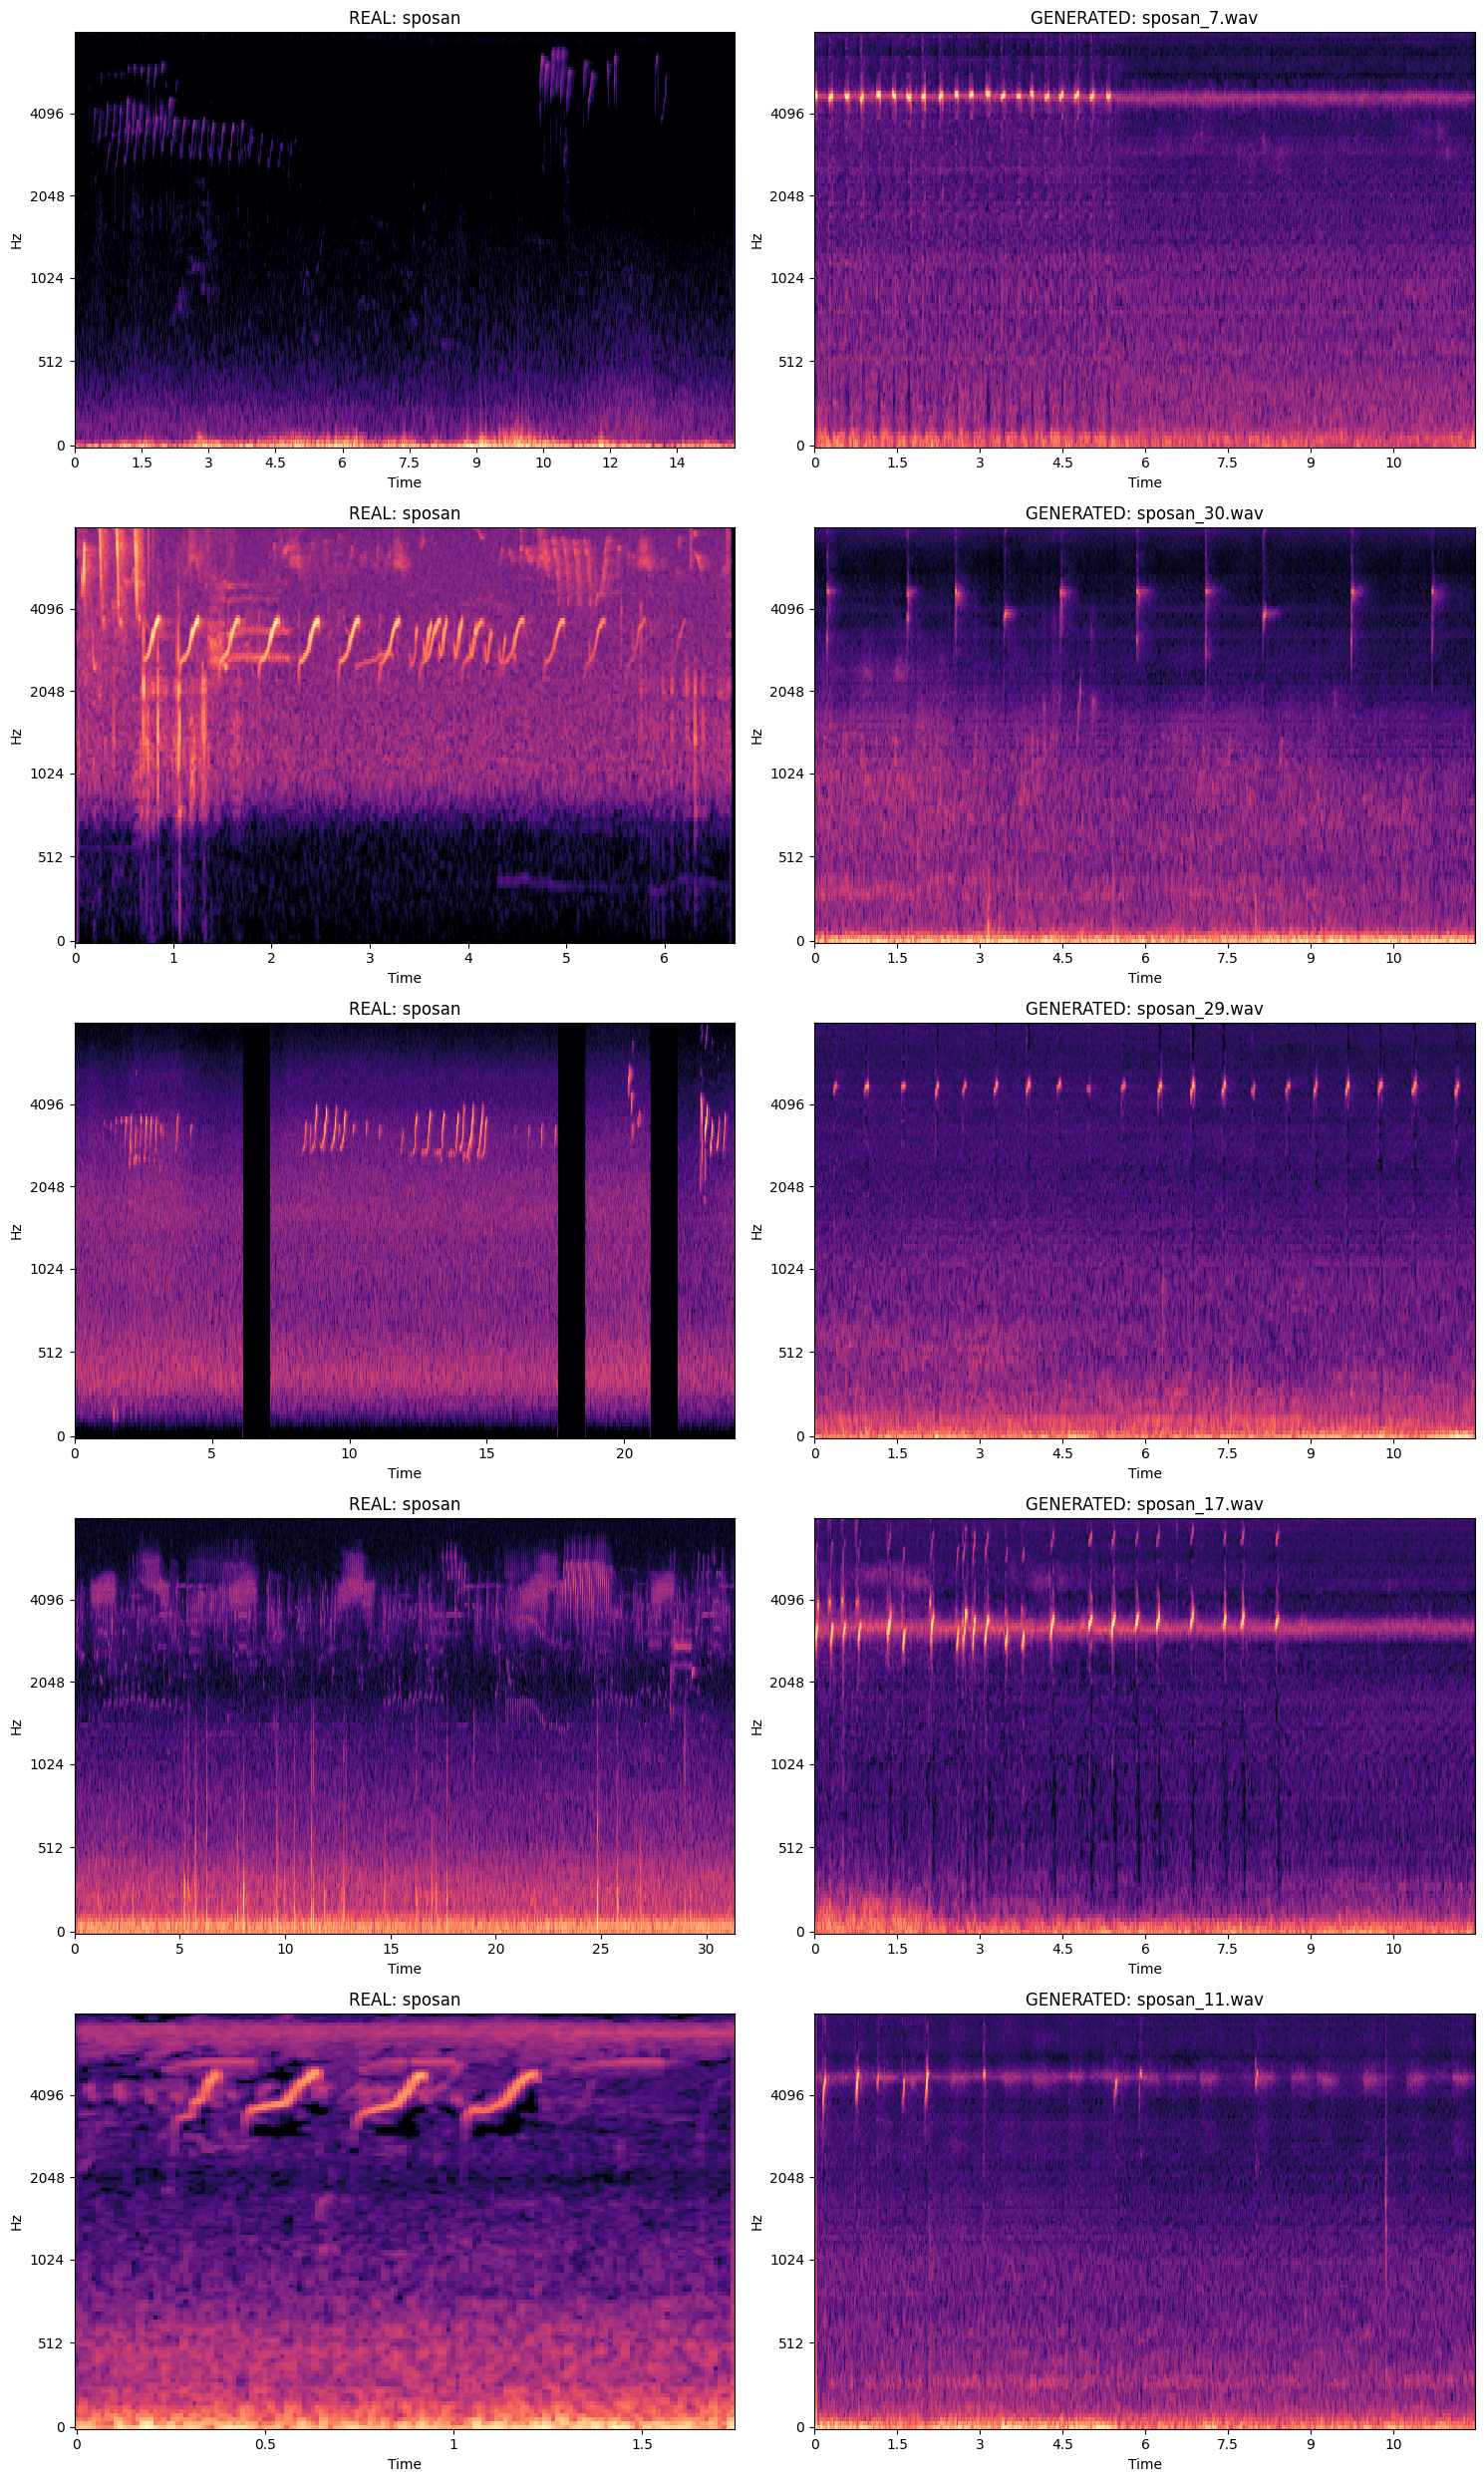

In [20]:
def plot_spectrogram(ax, audio_path, title):
    try:
        y, sr = librosa.load(audio_path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax, cmap='magma')
        ax.set_title(title)
        return img
    except Exception as e:
        print(f"Could not load {audio_path}: {e}")
        return None
    
def show_spectrogram(class_id, nr_samples, real_audio_dir, generated_audio_dir, class_mappings):
    with open(class_mappings, "r", encoding="utf-8") as file:
        class_mappings = json.load(file)
    class_name = next((key for key, val in class_mappings.items() if val["id"] == class_id), None)
    class_name = Path(class_name)

    real_files = list((real_audio_dir / class_name).rglob("*.wav"))
    gen_files = list((generated_audio_dir / class_name) .rglob("*.wav"))
    selected_real = random.sample(real_files, min(nr_samples, len(real_files)))
    selected_gen = random.sample(gen_files, min(nr_samples, len(gen_files)))

    fig, axes = plt.subplots(nrows=nr_samples, ncols=2, figsize=(15, 5 * nr_samples))
    for i in range(nr_samples):
        plot_spectrogram(axes[i, 0], selected_real[i], f"REAL: {class_name}")
        img = plot_spectrogram(axes[i, 1], selected_gen[i], f"GENERATED: {selected_gen[i].name}")
        
   # fig.colorbar(img, ax=axes, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
show_spectrogram(4, 5, real_audio_dir, generated_audio_dir, "class_mapping_runpod.json")